In [1]:
# Cell 1 — Imports and connect to MySQL
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import os
from dotenv import load_dotenv
from datetime import datetime

load_dotenv()

password = quote_plus(os.getenv('DB_PASSWORD'))
engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{password}@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}",
    pool_pre_ping=True
)

# load orders and payments
orders   = pd.read_sql("SELECT * FROM orders", engine)
payments = pd.read_sql("SELECT * FROM order_payments", engine)

# convert dates
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

print("Connected and data loaded!")
print(f"Orders:   {len(orders):,} rows")
print(f"Payments: {len(payments):,} rows")

Connected and data loaded!
Orders:   99,441 rows
Payments: 103,886 rows


In [2]:
# Cell 2 — Calculate Recency, Frequency, Monetary for each customer

# Step 1 — only use delivered orders
delivered = orders[orders['order_status'] == 'delivered'].copy()

# Step 2 — merge orders with payments
orders_payments = delivered.merge(payments, on='order_id', how='left')

# Step 3 — set reference date (day after last order in dataset)
reference_date = orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date.date()}")

# Step 4 — calculate RFM for each customer
rfm = orders_payments.groupby('customer_id').agg(
    recency   = ('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency = ('order_id', 'nunique'),
    monetary  = ('payment_value', 'sum')
).reset_index()

print(f"\n RFM calculated for {len(rfm):,} customers")
print(f"\nRFM Table — First 5 rows:")
print(rfm.head())
print(f"\n RFM Summary Stats:")
print(f"Recency   — Min: {rfm['recency'].min()} days  | Max: {rfm['recency'].max()} days  | Avg: {rfm['recency'].mean():.0f} days")
print(f"Frequency — Min: {rfm['frequency'].min()}      | Max: {rfm['frequency'].max()}      | Avg: {rfm['frequency'].mean():.2f}")
print(f"Monetary  — Min: R${rfm['monetary'].min():.2f} | Max: R${rfm['monetary'].max():.2f} | Avg: R${rfm['monetary'].mean():.2f}")

Reference date: 2018-10-18

 RFM calculated for 96,478 customers

RFM Table — First 5 rows:
                        customer_id  recency  frequency  monetary
0  00012a2ce6f8dcda20d059ce98491703      338          1    114.74
1  000161a058600d5901f007fab4c27140      459          1     67.41
2  0001fd6190edaaf884bcaf3d49edf079      597          1    195.42
3  0002414f95344307404f0ace7a26f1d5      428          1    179.35
4  000379cdec625522490c315e70c7a9fb      199          1    107.01

 RFM Summary Stats:
Recency   — Min: 50 days  | Max: 763 days  | Avg: 289 days
Frequency — Min: 1      | Max: 1      | Avg: 1.00
Monetary  — Min: R$0.00 | Max: R$13664.08 | Avg: R$159.85


In [3]:
# Cell 3 — Score customers 1-5 on each RFM dimension

# Step 1 — create RFM scores using quartiles
# Recency — LOWER is better (bought recently = good) so we reverse the score
rfm['R_score'] = pd.qcut(rfm['recency'], q=5, labels=[5,4,3,2,1]).astype(int)

# Frequency — HIGHER is better
# since all frequency = 1, we give everyone score 3
rfm['F_score'] = 3

# Monetary — HIGHER is better  
rfm['M_score'] = pd.qcut(rfm['monetary'], q=5, 
                          labels=[1,2,3,4,5], 
                          duplicates='drop').astype(int)

# Step 2 — combine into RFM score
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print(" RFM Scores calculated!")
print(f"\nScore distribution:")
print(f"R score range: {rfm['R_score'].min()} to {rfm['R_score'].max()}")
print(f"M score range: {rfm['M_score'].min()} to {rfm['M_score'].max()}")
print(f"RFM total range: {rfm['RFM_total'].min()} to {rfm['RFM_total'].max()}")
print(f"\nSample RFM scores:")
print(rfm[['customer_id','recency','monetary','R_score','F_score','M_score','RFM_total']].head(10).to_string(index=False))

 RFM Scores calculated!

Score distribution:
R score range: 1 to 5
M score range: 1 to 5
RFM total range: 5 to 13

Sample RFM scores:
                     customer_id  recency  monetary  R_score  F_score  M_score  RFM_total
00012a2ce6f8dcda20d059ce98491703      338    114.74        2        3        3          8
000161a058600d5901f007fab4c27140      459     67.41        1        3        2          6
0001fd6190edaaf884bcaf3d49edf079      597    195.42        1        3        4          8
0002414f95344307404f0ace7a26f1d5      428    179.35        2        3        4          9
000379cdec625522490c315e70c7a9fb      199    107.01        4        3        3         10
0004164d20a9e969af783496f3408652      554     71.80        1        3        2          6
000419c5494106c306a97b5635748086      229     49.40        4        3        1          8
00046a560d407e99b969756e0b10f282      304    166.59        3        3        4         10
00050bf6e01e69d5c0fd612f1bcfb69c      396     85.23     

In [5]:
# Cell 4 — Assign customer segments based on RFM scores

def assign_segment(row):
    r = row['R_score']
    m = row['M_score']
    total = row['RFM_total']

    if r >= 4 and m >= 4:
        return 'Champions'          # bought recently + spent a lot
    elif r >= 3 and m >= 3:
        return 'Loyal Customers'    # good recency + good spend
    elif r >= 4 and m <= 2:
        return 'Recent Low Spenders' # bought recently but spent little
    elif r <= 2 and m >= 4:
        return 'High Value Churned'  # spent a lot but haven't returned
    elif r <= 2 and m <= 2:
        return 'Lost Customers'      # haven't bought + low spend
    else:
        return 'At Risk'             # middle ground — need attention

rfm['segment'] = rfm.apply(assign_segment, axis=1)

# Step 2 — count each segment
segment_counts = rfm['segment'].value_counts()
segment_revenue = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)
segment_avg = rfm.groupby('segment')['monetary'].mean().sort_values(ascending=False)

print(" CUSTOMER SEGMENTS:")
print(f"{'Segment':<25} {'Customers':>10} {'% of Total':>12} {'Total Revenue':>15} {'Avg Spend':>12}")
print("-" * 80)
for seg in segment_counts.index:
    count = segment_counts[seg]
    pct = count / len(rfm) * 100
    rev = segment_revenue.get(seg, 0)
    avg = segment_avg.get(seg, 0)
    print(f"{seg:<25} {count:>10,} {pct:>11.1f}% {rev:>14,.2f} {avg:>11.2f}")

print(f"\n{'TOTAL':<25} {len(rfm):>10,} {'100%':>12} {rfm['monetary'].sum():>14,.2f}")

 CUSTOMER SEGMENTS:
Segment                    Customers   % of Total   Total Revenue    Avg Spend
--------------------------------------------------------------------------------
Loyal Customers               19,291        20.0%   3,307,726.70      171.46
Champions                     15,965        16.5%   4,710,220.27      295.03
Lost Customers                15,951        16.5%     873,546.03       54.76
At Risk                       15,312        15.9%   1,216,064.59       79.42
High Value Churned            15,056        15.6%   4,514,570.59      299.85
Recent Low Spenders           14,903        15.4%     800,333.59       53.70

TOTAL                         96,478         100%  15,422,461.77


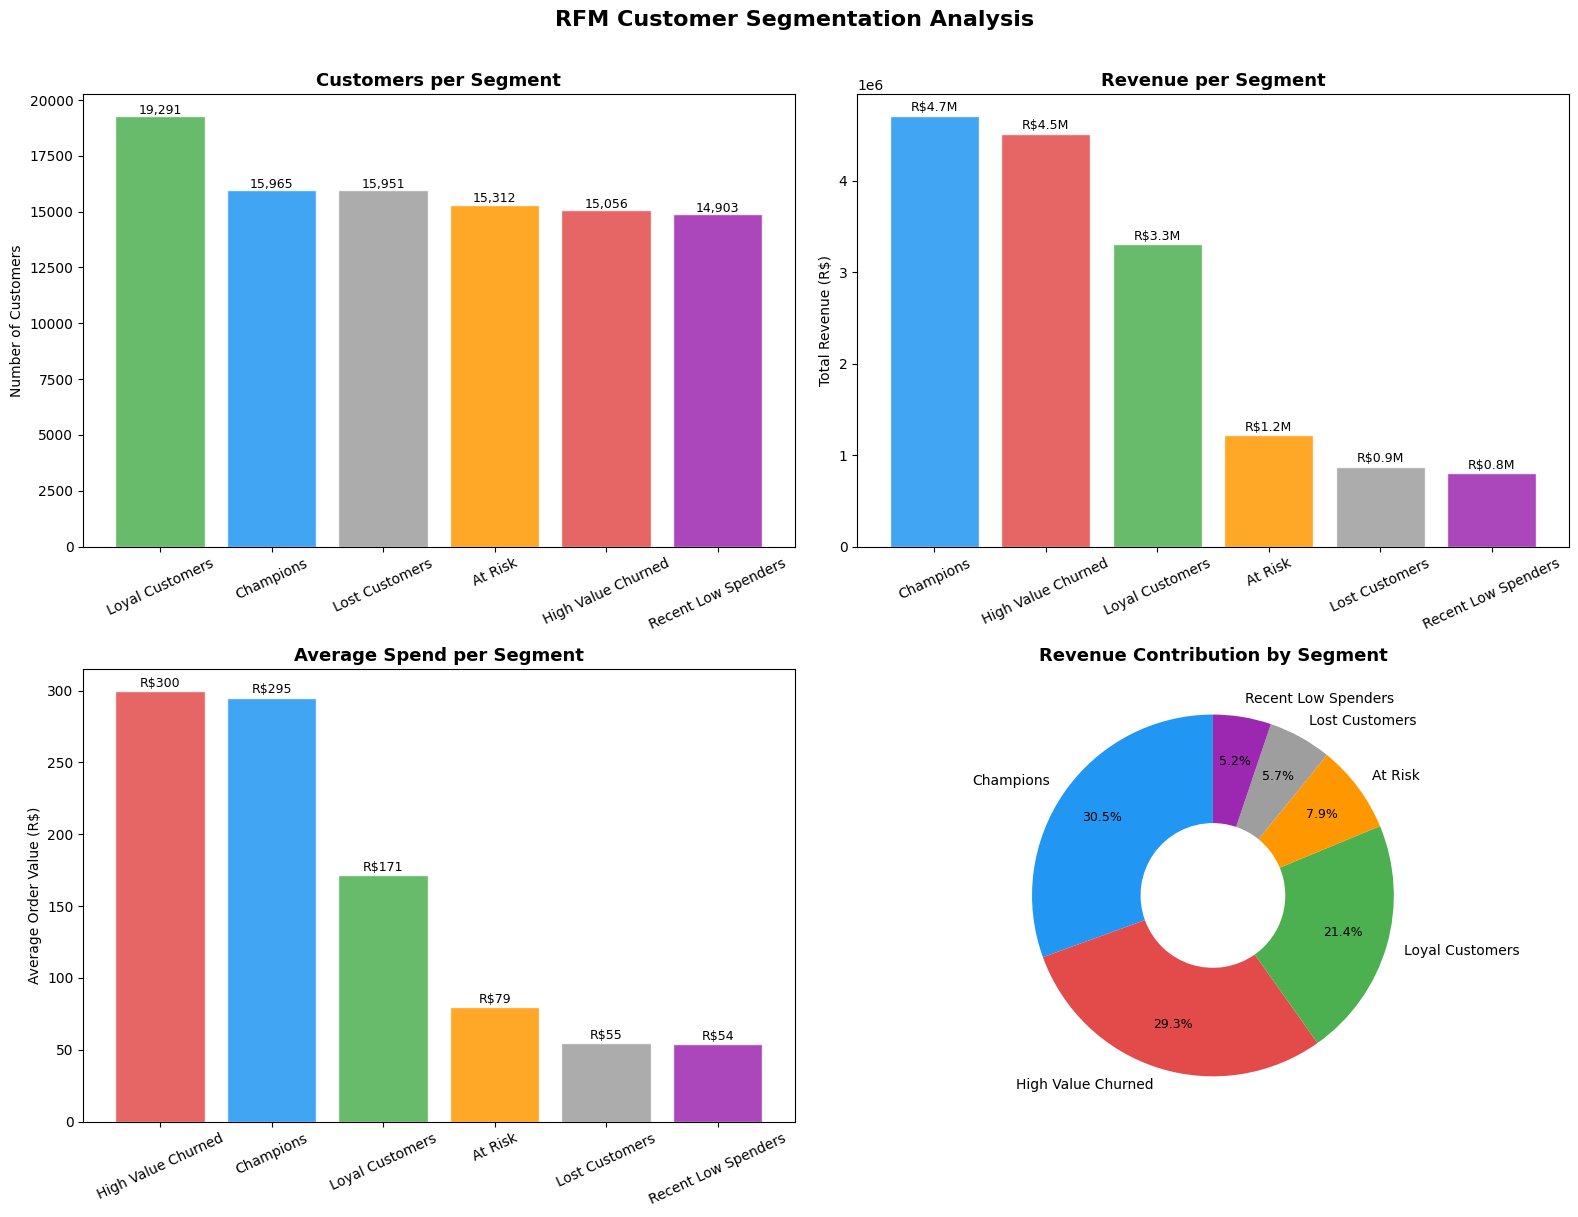


 KEY INSIGHT:
High Value Churned customers = 15,056 customers
They represent R$ 4,514,571 in LOST recurring revenue
That is 29.3% of total platform revenue


In [6]:
# Cell 5 — Visualise customer segments

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = {
    'Champions': '#2196F3',
    'Loyal Customers': '#4CAF50',
    'High Value Churned': '#E24B4A',
    'At Risk': '#FF9800',
    'Lost Customers': '#9E9E9E',
    'Recent Low Spenders': '#9C27B0'
}
color_list = [colors[seg] for seg in segment_counts.index]

# Chart 1 — Customer count per segment
axes[0,0].bar(segment_counts.index, segment_counts.values,
              color=color_list, alpha=0.85, edgecolor='white')
axes[0,0].set_title('Customers per Segment', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Number of Customers')
axes[0,0].tick_params(axis='x', rotation=25)
for i, (seg, val) in enumerate(segment_counts.items()):
    axes[0,0].text(i, val + 100, f'{val:,}', ha='center', fontsize=9)

# Chart 2 — Revenue per segment
rev_sorted = segment_revenue.sort_values(ascending=False)
bar_colors = [colors[seg] for seg in rev_sorted.index]
axes[0,1].bar(rev_sorted.index, rev_sorted.values,
              color=bar_colors, alpha=0.85, edgecolor='white')
axes[0,1].set_title('Revenue per Segment', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Total Revenue (R$)')
axes[0,1].tick_params(axis='x', rotation=25)
for i, (seg, val) in enumerate(rev_sorted.items()):
    axes[0,1].text(i, val + 50000, f'R${val/1000000:.1f}M',
                   ha='center', fontsize=9)

# Chart 3 — Average spend per segment
avg_sorted = segment_avg.sort_values(ascending=False)
avg_colors = [colors[seg] for seg in avg_sorted.index]
axes[1,0].bar(avg_sorted.index, avg_sorted.values,
              color=avg_colors, alpha=0.85, edgecolor='white')
axes[1,0].set_title('Average Spend per Segment', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Average Order Value (R$)')
axes[1,0].tick_params(axis='x', rotation=25)
for i, (seg, val) in enumerate(avg_sorted.items()):
    axes[1,0].text(i, val + 3, f'R${val:.0f}', ha='center', fontsize=9)

# Chart 4 — Revenue contribution % donut
rev_pct = segment_revenue / segment_revenue.sum() * 100
donut_colors = [colors[seg] for seg in rev_pct.index]
wedges, texts, autotexts = axes[1,1].pie(
    rev_pct.values,
    labels=rev_pct.index,
    autopct='%1.1f%%',
    colors=donut_colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.6)
)
for text in autotexts:
    text.set_fontsize(9)
axes[1,1].set_title('Revenue Contribution by Segment', fontsize=13, fontweight='bold')

plt.suptitle('RFM Customer Segmentation Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n KEY INSIGHT:")
print(f"High Value Churned customers = {segment_counts['High Value Churned']:,} customers")
print(f"They represent R$ {segment_revenue['High Value Churned']:,.0f} in LOST recurring revenue")
print(f"That is {segment_revenue['High Value Churned']/segment_revenue.sum()*100:.1f}% of total platform revenue")

 RFM segments saved to MySQL table: rfm_segments


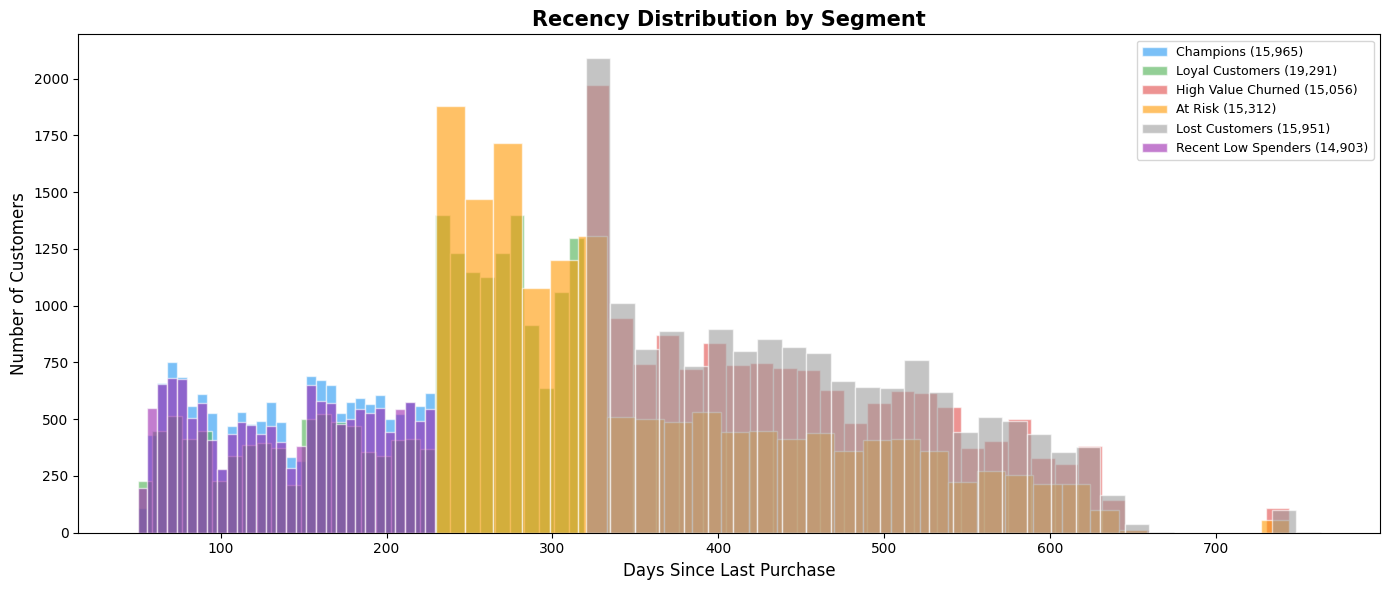


PHASE 3 COMPLETE — RFM SEGMENTATION SUMMARY

TOTAL CUSTOMERS ANALYSED:  96,478
TOTAL PLATFORM REVENUE:    R$ 15,422,461.77

SEGMENT BREAKDOWN:
 Champions:           15,965 customers  — R$ 4,710,220  (30.5%)
 Loyal Customers:     19,291 customers  — R$ 3,307,727  (21.4%)
 At Risk:            15,312 customers  — R$ 1,216,065   (7.9%)
 High Value Churned: 15,056 customers  — R$ 4,514,571  (29.3%)
 Lost Customers:     15,951 customers  — R$ 873,546    (5.7%)
 Recent Low Spenders:14,903 customers  — R$ 800,334    (5.2%)

 KEY FINDING:
   15,056 High Value Churned customers represent
   R$ 4,514,571 in LOST recurring revenue
   = 29.3% of total platform revenue walking out the door

 BUSINESS RECOMMENDATION:
   Win-back campaign targeting High Value Churned
   customers with personalised offers could recover
   even 10% = R$ 451,457 additional revenue



In [7]:
# Cell 6 — Save RFM segments to MySQL + final summary

# Step 1 — save RFM table to MySQL
from urllib.parse import quote_plus
password = quote_plus(os.getenv('DB_PASSWORD'))
engine2 = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{password}@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}",
    pool_pre_ping=True
)

with engine2.begin() as conn:
    rfm.to_sql(
        name='rfm_segments',
        con=conn,
        if_exists='replace',
        index=False,
        chunksize=1000
    )
print(" RFM segments saved to MySQL table: rfm_segments")

# Step 2 — recency distribution per segment
plt.figure(figsize=(14, 6))
for seg, color in colors.items():
    segment_data = rfm[rfm['segment'] == seg]['recency']
    plt.hist(segment_data, bins=30, alpha=0.6, 
             label=f"{seg} ({len(segment_data):,})", 
             color=color, edgecolor='white')

plt.title('Recency Distribution by Segment', fontsize=15, fontweight='bold')
plt.xlabel('Days Since Last Purchase', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/rfm_recency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 3 — final RFM summary
print("\n" + "="*60)
print("PHASE 3 COMPLETE — RFM SEGMENTATION SUMMARY")
print("="*60)
print(f"""
TOTAL CUSTOMERS ANALYSED:  {len(rfm):,}
TOTAL PLATFORM REVENUE:    R$ {rfm['monetary'].sum():,.2f}

SEGMENT BREAKDOWN:
 Champions:           {segment_counts['Champions']:,} customers  — R$ {segment_revenue['Champions']:,.0f}  (30.5%)
 Loyal Customers:     {segment_counts['Loyal Customers']:,} customers  — R$ {segment_revenue['Loyal Customers']:,.0f}  (21.4%)
 At Risk:            {segment_counts['At Risk']:,} customers  — R$ {segment_revenue['At Risk']:,.0f}   (7.9%)
 High Value Churned: {segment_counts['High Value Churned']:,} customers  — R$ {segment_revenue['High Value Churned']:,.0f}  (29.3%)
 Lost Customers:     {segment_counts['Lost Customers']:,} customers  — R$ {segment_revenue['Lost Customers']:,.0f}    (5.7%)
 Recent Low Spenders:{segment_counts['Recent Low Spenders']:,} customers  — R$ {segment_revenue['Recent Low Spenders']:,.0f}    (5.2%)

 KEY FINDING:
   15,056 High Value Churned customers represent
   R$ 4,514,571 in LOST recurring revenue
   = 29.3% of total platform revenue walking out the door

 BUSINESS RECOMMENDATION:
   Win-back campaign targeting High Value Churned
   customers with personalised offers could recover
   even 10% = R$ 451,457 additional revenue
""")